### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [111]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, Model

### Step 2: Load Data

In [11]:
df = pd.read_csv('./data/FakeNewsDetectionModel.csv', usecols=['title', 'text', 'label'])

In [13]:
df.shape

(6335, 3)

In [12]:
df.head()

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


### Step 3: Exploaring Data

#### Basic Info

In [17]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': 100 * df.isnull().sum() / len(df),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [18]:
feature_info

,null,null(%),unique,type
title,0,0.0,6256,object
text,0,0.0,6060,object
label,0,0.0,2,object


#### Target Distribution

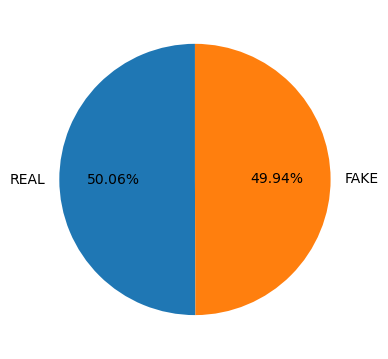

In [21]:
temp = df['label'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    labels=temp.index,
    autopct='%.2f%%',
    startangle=90
)
plt.tight_layout()

### Step 4: Feature Engineering

#### Variables Setup

In [82]:
embedding_dim = 50
max_length = 60
padding_type = 'post'
trunc_type = 'post'
oov_tok = '<OOV>'

#### Label Encode

In [22]:
le = LabelEncoder()

In [23]:
df['label'] = le.fit_transform(df['label'])

#### Tokenization 

In [28]:
tokenizer = Tokenizer(oov_token=oov_tok)

In [29]:
tokenizer.fit_on_texts(df['title'])

In [32]:
sequences = tokenizer.texts_to_sequences(df['title'])

In [86]:
word_index = tokenizer.word_index
vocab_size = len(word_index)

#### Padding

In [38]:
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

### Step 5: Preparing Data

#### Split Data

In [134]:
target = df['label'].values

In [135]:
X_train, X_test, y_train, y_test = train_test_split(
    padded,
    target,
    test_size=0.2,
    random_state=42
)

#### Embedding

In [80]:
embedding_index = dict()
with open('./data/glove.6B/glove.6B.50d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

In [144]:
embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))

In [145]:
for word, i in word_index.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

### Step 6: Model Development

In [161]:
inputs = layers.Input(shape=(max_length,))
x = layers.Embedding(
    vocab_size+1, 
    embedding_dim, 
    input_length=max_length, 
    weights=[embedding_matrix], 
    trainable=False
)(inputs)
x = layers.Dropout(0.5)(x)
x = layers.Conv1D(64, 5, activation='relu')(x)
x = layers.MaxPooling1D(pool_size=4)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(64)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

In [162]:
model = Model(inputs, outputs)

In [163]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 60)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 60, 50)              │         586,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 56, 64)              │          16,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 14, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_4 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 635,303 (2.42 MB)

 Trainable params: 49,153 (192.00 KB)

 Non-trainable params: 586,150 (2.24 MB)

In [164]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [165]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    validation_data=(X_test, y_test), 
    verbose=2
)

Epoch 1/50
159/159 - 2s - 13ms/step - accuracy: 0.5929 - loss: 0.6593 - val_accuracy: 0.6709 - val_loss: 0.6190
Epoch 2/50
159/159 - 1s - 6ms/step - accuracy: 0.6537 - loss: 0.6196 - val_accuracy: 0.7017 - val_loss: 0.5695
Epoch 3/50
159/159 - 1s - 7ms/step - accuracy: 0.6685 - loss: 0.6078 - val_accuracy: 0.7096 - val_loss: 0.5619
Epoch 4/50
159/159 - 1s - 6ms/step - accuracy: 0.6786 - loss: 0.5963 - val_accuracy: 0.7064 - val_loss: 0.5452
Epoch 5/50
159/159 - 1s - 6ms/step - accuracy: 0.6869 - loss: 0.5869 - val_accuracy: 0.6969 - val_loss: 0.5566
Epoch 6/50
159/159 - 1s - 6ms/step - accuracy: 0.6997 - loss: 0.5796 - val_accuracy: 0.7096 - val_loss: 0.5421
Epoch 7/50
159/159 - 1s - 6ms/step - accuracy: 0.6981 - loss: 0.5731 - val_accuracy: 0.7072 - val_loss: 0.5434
Epoch 8/50
159/159 - 1s - 6ms/step - accuracy: 0.7003 - loss: 0.5625 - val_accuracy: 0.7064 - val_loss: 0.5372
Epoch 9/50
159/159 - 1s - 6ms/step - accuracy: 0.6977 - loss: 0.5705 - val_accuracy: 0.7174 - val_loss: 0.5361


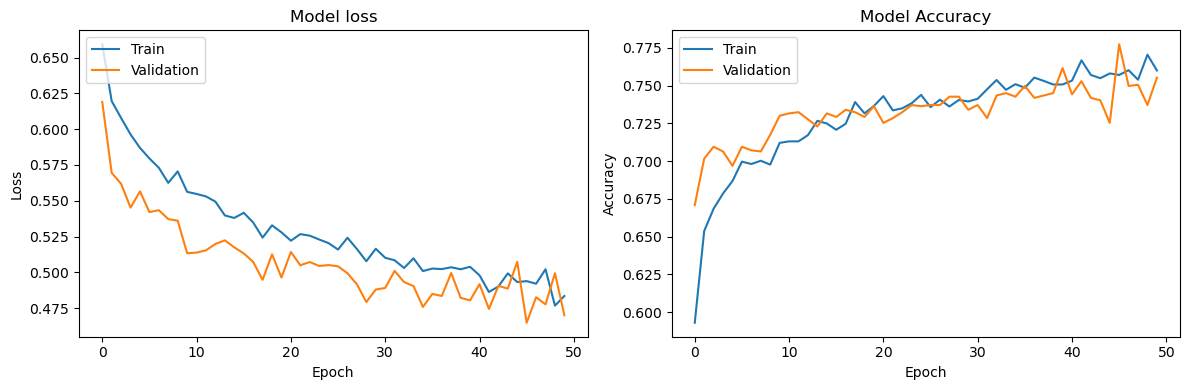

In [166]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()

In [167]:
temp = "Karry to go to France in gesture of sympathy"

In [170]:
sequences = tokenizer.texts_to_sequences([temp])

In [171]:
sequences = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

In [172]:
if model.predict(sequences, verbose=0)[0][0] >= 0.5:
    print("This news is True")
else:
    print("This news is False")

This news is False
